<a href="https://colab.research.google.com/github/metel152/Volans-tarkvara/blob/Programmid-graafikute-jaoks/Automaatne_graafik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   row_id       mission_id source  seq           timestamp  temp_C  \
0       1  20260428_005743   TEST    1  2026-04-28 0:57:58   19.45   
1       2  20260428_005743   TEST    2  2026-04-28 0:58:00   19.58   
2       3  20260428_005743   TEST    3  2026-04-28 0:58:01   19.70   
3       4  20260428_005743   TEST    4  2026-04-28 0:58:02   19.88   
4       5  20260428_005743   TEST    5  2026-04-28 0:58:03   20.02   

   pressure_hPa  alt_m     ax     ay     az     gx     gy    gz  peak_alt_m  \
0       1003.08  85.00 -0.000  0.000  1.000  35.00  22.00  0.00       85.00   
1       1002.24  92.06 -0.049  0.119  0.992  33.55  21.56  2.06       92.06   
2       1001.85  95.37 -0.086  0.205  0.975  30.40  20.60  3.60       95.37   
3       1001.88  95.07 -0.133  0.303  0.944  23.48  18.42  5.46       95.37   
4       1002.10  93.25 -0.164  0.355  0.920  16.77  16.22  6.57       95.37   

   descent_count  deployed deploy_reason  
0              0         0          NONE  
1              0  

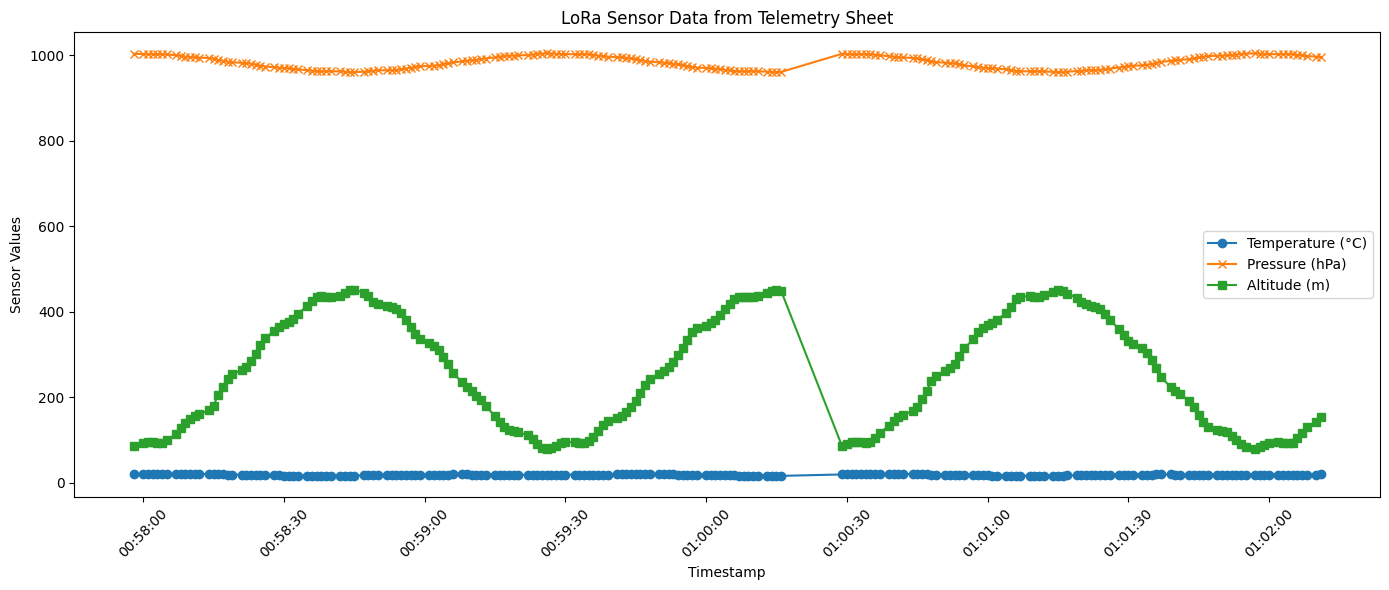

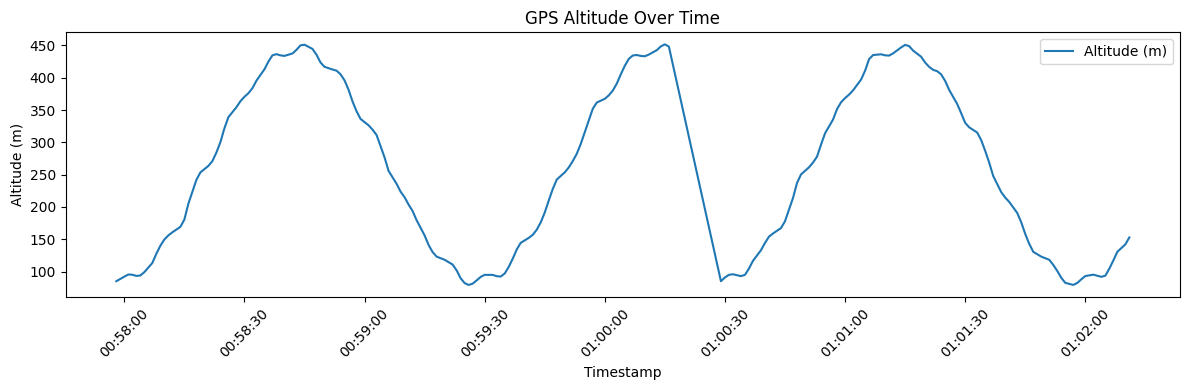

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Step 1: Google Sheet setup
# ----------------------------
sheet_id = "1KMH23124r0dfmFmYDiJ3dQ1vFEoOMmUcdY_b5E81EX0"

# Replace this with the actual gid of the "telemetry" tab

csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet=Telemetry_TEST"
# Build a stable CSV export URL

# ----------------------------
# Step 2: Read latest data
# ----------------------------
df = pd.read_csv(csv_url)

# Debug (optional but useful)
print(df.head())
print(df.columns)

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# ----------------------------
# Step 3: Plotting all sensors
# ----------------------------
plt.figure(figsize=(14,6))

plt.plot(df['timestamp'], df['temp_C'], label='Temperature (°C)', marker='o')
plt.plot(df['timestamp'], df['pressure_hPa'], label='Pressure (hPa)', marker='x')
plt.plot(df['timestamp'], df['alt_m'], label='Altitude (m)', marker='s')

plt.xlabel('Timestamp')
plt.ylabel('Sensor Values')
plt.title('LoRa Sensor Data from Telemetry Sheet')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Step 4: Optional separate graph for Altitude
# ----------------------------
plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], df['alt_m'], label='Altitude (m)')

plt.xlabel('Timestamp')
plt.ylabel('Altitude (m)')
plt.title('GPS Altitude Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()